# Basic Enhancement in Digital Image Processing
**CMSC 178IP Interactive Workshop**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/your-repo/CMSC178IP/blob/main/03-BasicEnhancement/notebooks/basic_enhancement_workshop.ipynb)

## 🎯 Learning Objectives
By the end of this workshop, you will be able to:
- Understand and apply histogram-based enhancement techniques
- Implement point operations for brightness and contrast adjustment
- Apply spatial filtering for noise reduction and sharpening
- Evaluate enhancement results using quality metrics
- Choose appropriate enhancement techniques for different scenarios

**Estimated Duration:** 45-60 minutes

## 1. Setup & Imports
Let's prepare our environment with the necessary libraries.

In [1]:
# Install required packages for Colab compatibility
import sys
if 'google.colab' in sys.modules:
    !pip install scikit-image opencv-python-headless

# Core imports
import numpy as np
import matplotlib.pyplot as plt
import cv2
from skimage import data, exposure, filters, color
from scipy import ndimage
import warnings
warnings.filterwarnings('ignore')

# Configure matplotlib
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10
plt.style.use('default')

print("✅ Environment setup complete!")
print(f"OpenCV version: {cv2.__version__}")
print(f"NumPy version: {np.__version__}")

✅ Environment setup complete!
OpenCV version: 4.12.0
NumPy version: 2.3.3


## 2. Part 1: Problem Understanding
Let's start by understanding what image enhancement means and why it's important.

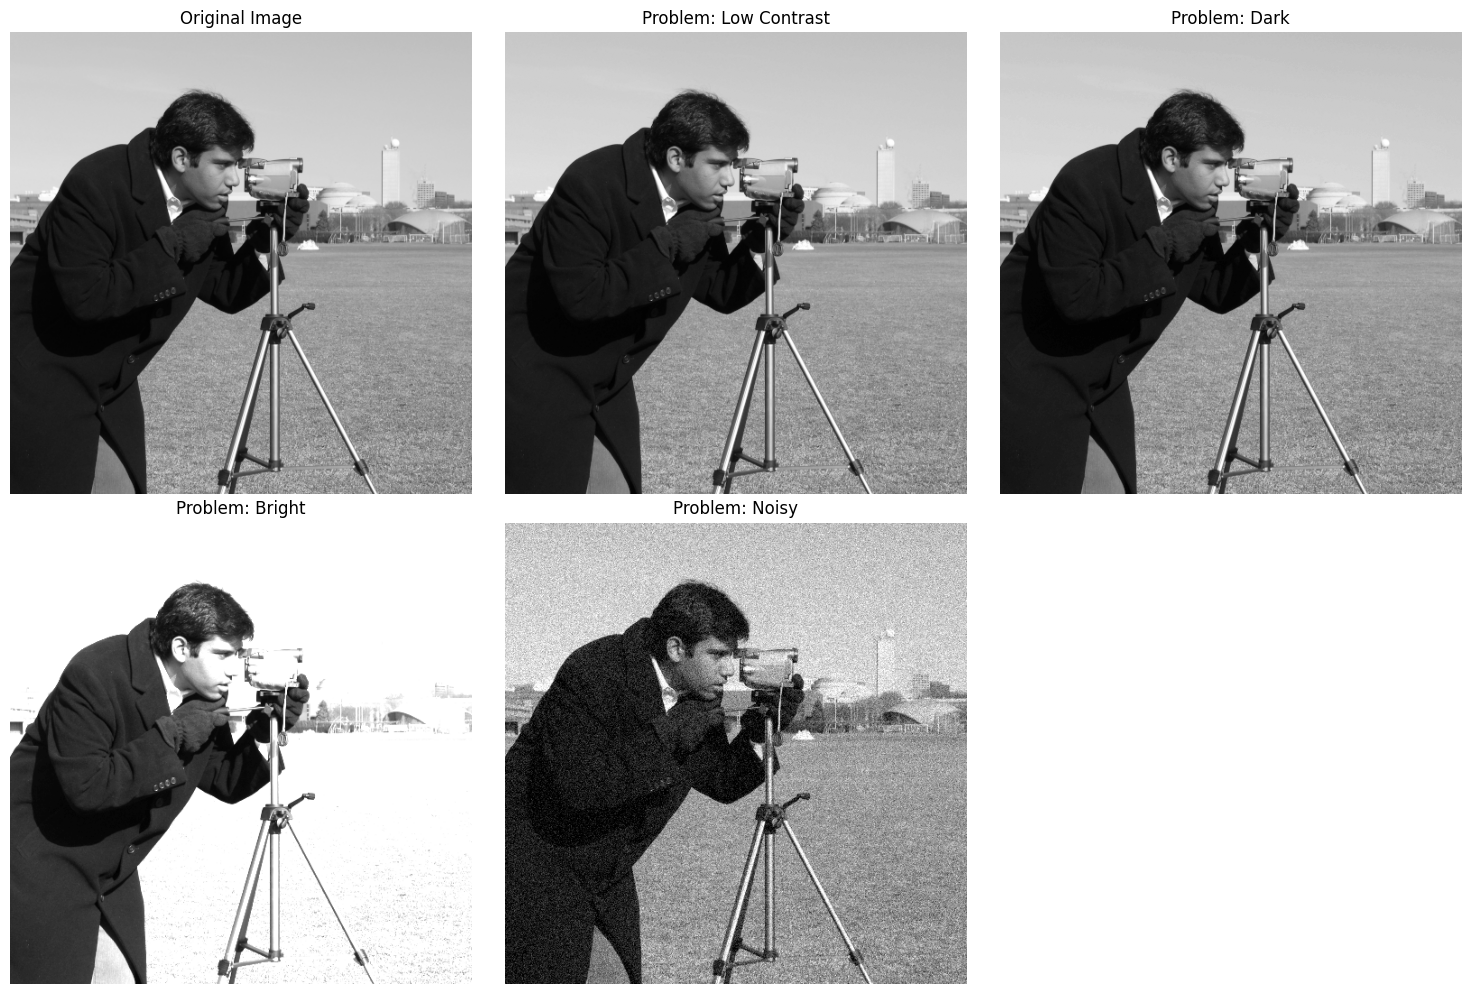

🔍 These are common image problems that enhancement techniques can solve:
• Low contrast - details are hard to see
• Too dark - underexposed images
• Too bright - overexposed images
• Noisy - interference from sensors or transmission


In [2]:
# Load sample images to demonstrate enhancement needs
def load_sample_images():
    """Load various sample images for demonstration."""
    images = {
        'camera': data.camera(),
        'coins': data.coins(),
        'moon': data.moon(),
        'astronaut': data.astronaut()
    }
    return images

def create_problematic_images(original):
    """Create images with common problems that need enhancement."""
    problems = {}
    
    # Low contrast
    problems['low_contrast'] = (original * 0.5 + 60).astype(np.uint8)
    
    # Too dark
    problems['dark'] = (original * 0.4).astype(np.uint8)
    
    # Too bright
    problems['bright'] = np.clip(original * 1.5 + 50, 0, 255).astype(np.uint8)
    
    # Noisy
    noise = np.random.normal(0, 20, original.shape)
    problems['noisy'] = np.clip(original.astype(float) + noise, 0, 255).astype(np.uint8)
    
    return problems

# Demonstrate the need for enhancement
samples = load_sample_images()
camera_problems = create_problematic_images(samples['camera'])

# Visualize problematic images
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

axes[0].imshow(samples['camera'], cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

for i, (problem, img) in enumerate(camera_problems.items(), 1):
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f'Problem: {problem.replace("_", " ").title()}')
    axes[i].axis('off')

# Remove empty subplot
axes[5].remove()

plt.tight_layout()
plt.show()

print("🔍 These are common image problems that enhancement techniques can solve:")
print("• Low contrast - details are hard to see")
print("• Too dark - underexposed images")
print("• Too bright - overexposed images") 
print("• Noisy - interference from sensors or transmission")

## 3. Part 2: Core Methods
Now let's implement the fundamental enhancement techniques step by step.

### 3.1 Histogram Analysis and Equalization

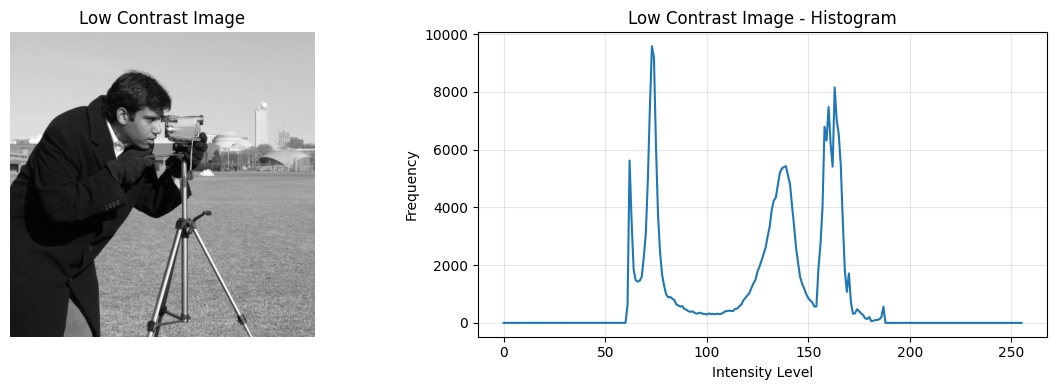

📊 Low Contrast Image Statistics:
  Mean: 124.3
  Std:  36.8
  Min:  60
  Max:  187



In [3]:
def analyze_histogram(image, title="Image"):
    """Analyze and visualize image histogram."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # Display image
    ax1.imshow(image, cmap='gray')
    ax1.set_title(f'{title}')
    ax1.axis('off')
    
    # Display histogram
    hist = cv2.calcHist([image], [0], None, [256], [0, 256])
    ax2.plot(hist)
    ax2.set_title(f'{title} - Histogram')
    ax2.set_xlabel('Intensity Level')
    ax2.set_ylabel('Frequency')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print(f"📊 {title} Statistics:")
    print(f"  Mean: {np.mean(image):.1f}")
    print(f"  Std:  {np.std(image):.1f}")
    print(f"  Min:  {np.min(image)}")
    print(f"  Max:  {np.max(image)}")
    print()

# Analyze the low contrast image
analyze_histogram(camera_problems['low_contrast'], "Low Contrast Image")

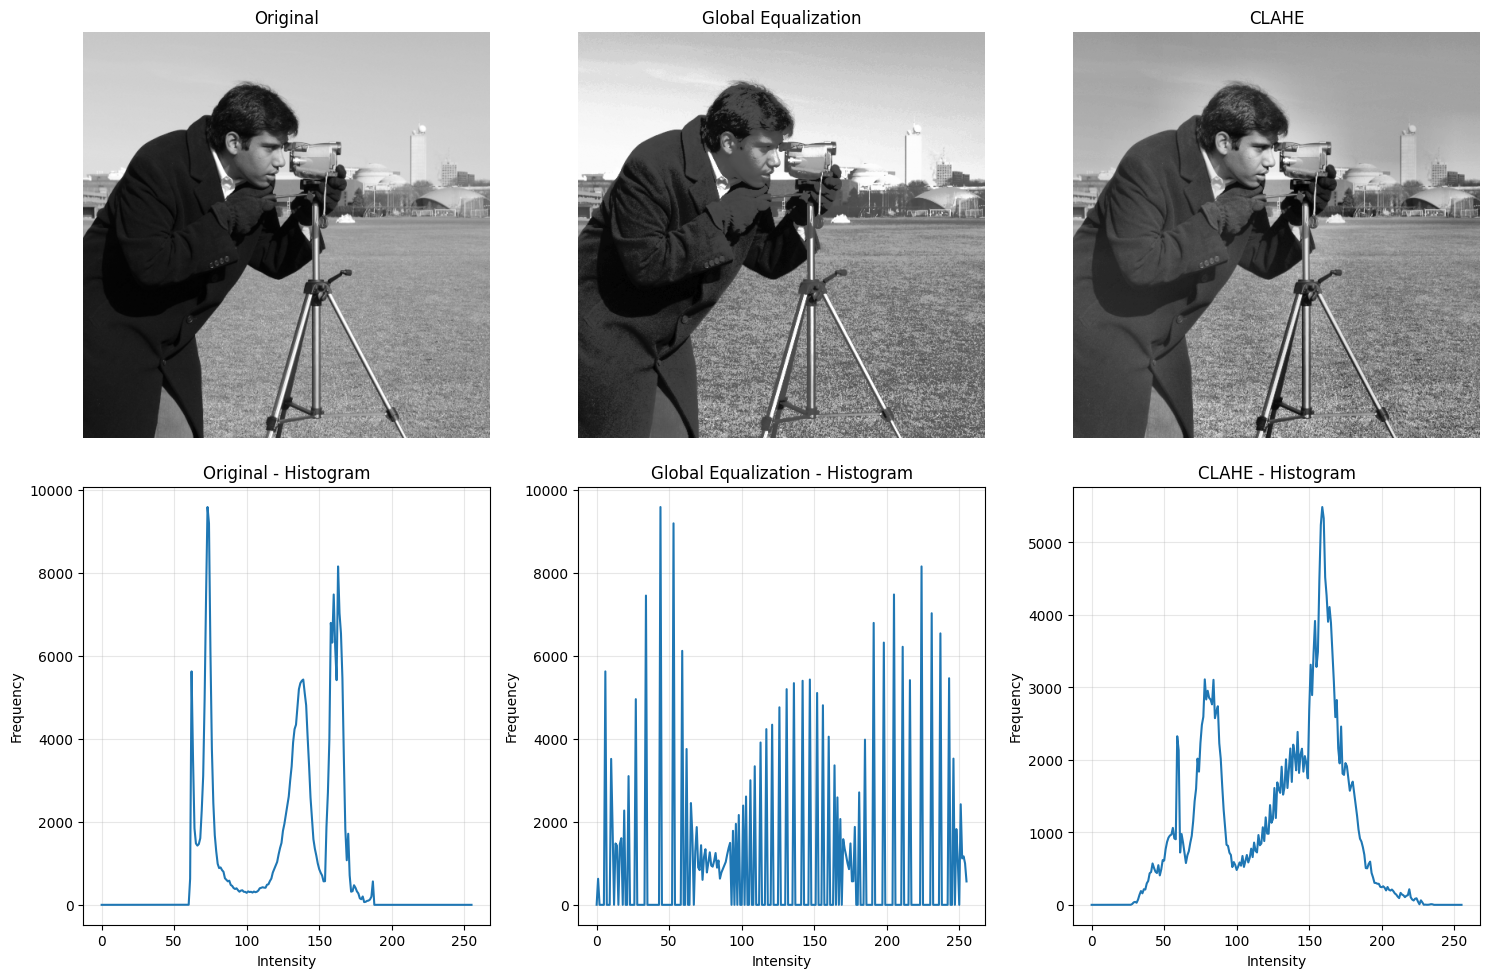

🔄 Histogram equalization redistributes pixel intensities for better contrast
📈 CLAHE prevents over-amplification in uniform regions


In [4]:
def histogram_equalization_demo(image):
    """Demonstrate histogram equalization."""
    # Apply histogram equalization
    equalized = cv2.equalizeHist(image)
    
    # Apply CLAHE (Contrast Limited Adaptive Histogram Equalization)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    clahe_result = clahe.apply(image)
    
    # Visualize results
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    images = [image, equalized, clahe_result]
    titles = ['Original', 'Global Equalization', 'CLAHE']
    
    for i, (img, title) in enumerate(zip(images, titles)):
        # Display image
        axes[0, i].imshow(img, cmap='gray')
        axes[0, i].set_title(title)
        axes[0, i].axis('off')
        
        # Display histogram
        hist = cv2.calcHist([img], [0], None, [256], [0, 256])
        axes[1, i].plot(hist)
        axes[1, i].set_title(f'{title} - Histogram')
        axes[1, i].set_xlabel('Intensity')
        axes[1, i].set_ylabel('Frequency')
        axes[1, i].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return equalized, clahe_result

# Demonstrate histogram equalization
eq_result, clahe_result = histogram_equalization_demo(camera_problems['low_contrast'])

print("🔄 Histogram equalization redistributes pixel intensities for better contrast")
print("📈 CLAHE prevents over-amplification in uniform regions")

### 3.2 Point Operations

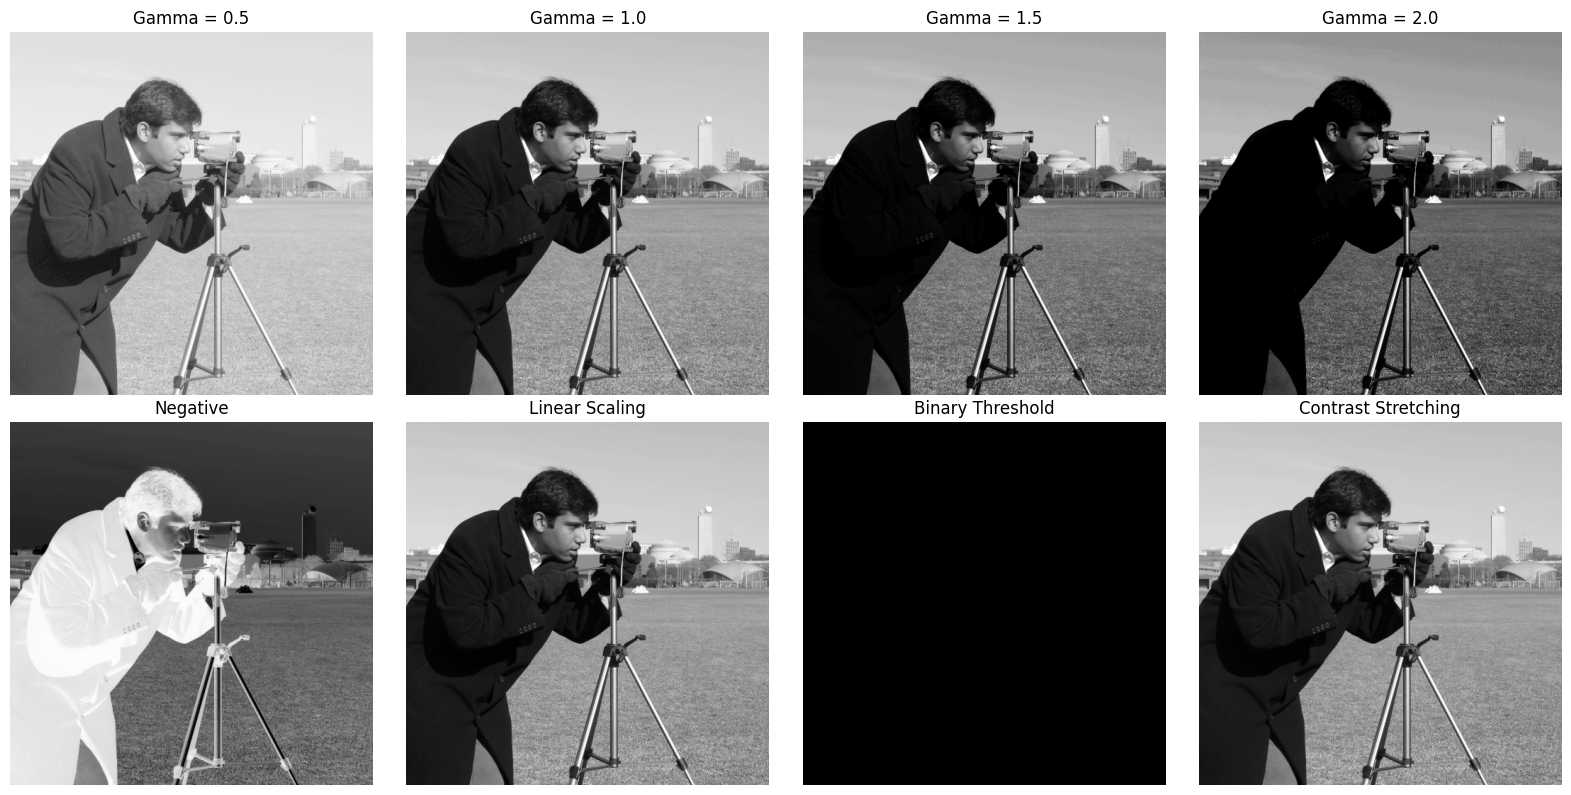

⚡ Point operations transform individual pixel values:
  • Gamma < 1: brightens image
  • Gamma > 1: darkens image
  • Linear scaling: adjusts contrast
  • Thresholding: creates binary images


In [5]:
def gamma_correction(image, gamma):
    """Apply gamma correction to image."""
    # Normalize to [0,1], apply gamma, scale back to [0,255]
    normalized = image.astype(float) / 255.0
    corrected = np.power(normalized, gamma)
    return (corrected * 255).astype(np.uint8)

def demonstrate_point_operations(image):
    """Demonstrate various point operations."""
    # Different gamma values
    gamma_values = [0.5, 1.0, 1.5, 2.0]
    
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    
    # Gamma correction results
    for i, gamma in enumerate(gamma_values):
        corrected = gamma_correction(image, gamma)
        axes[0, i].imshow(corrected, cmap='gray')
        axes[0, i].set_title(f'Gamma = {gamma}')
        axes[0, i].axis('off')
    
    # Other point operations
    operations = [
        (255 - image, "Negative"),
        (np.clip(image * 1.5, 0, 255).astype(np.uint8), "Linear Scaling"),
        (np.where(image > 128, 255, 0).astype(np.uint8), "Binary Threshold"),
        (exposure.rescale_intensity(image), "Contrast Stretching")
    ]
    
    for i, (result, title) in enumerate(operations):
        axes[1, i].imshow(result, cmap='gray')
        axes[1, i].set_title(title)
        axes[1, i].axis('off')
    
    plt.tight_layout()
    plt.show()

# Demonstrate point operations
demonstrate_point_operations(camera_problems['dark'])

print("⚡ Point operations transform individual pixel values:")
print("  • Gamma < 1: brightens image")
print("  • Gamma > 1: darkens image")
print("  • Linear scaling: adjusts contrast")
print("  • Thresholding: creates binary images")

### 3.3 Spatial Filtering

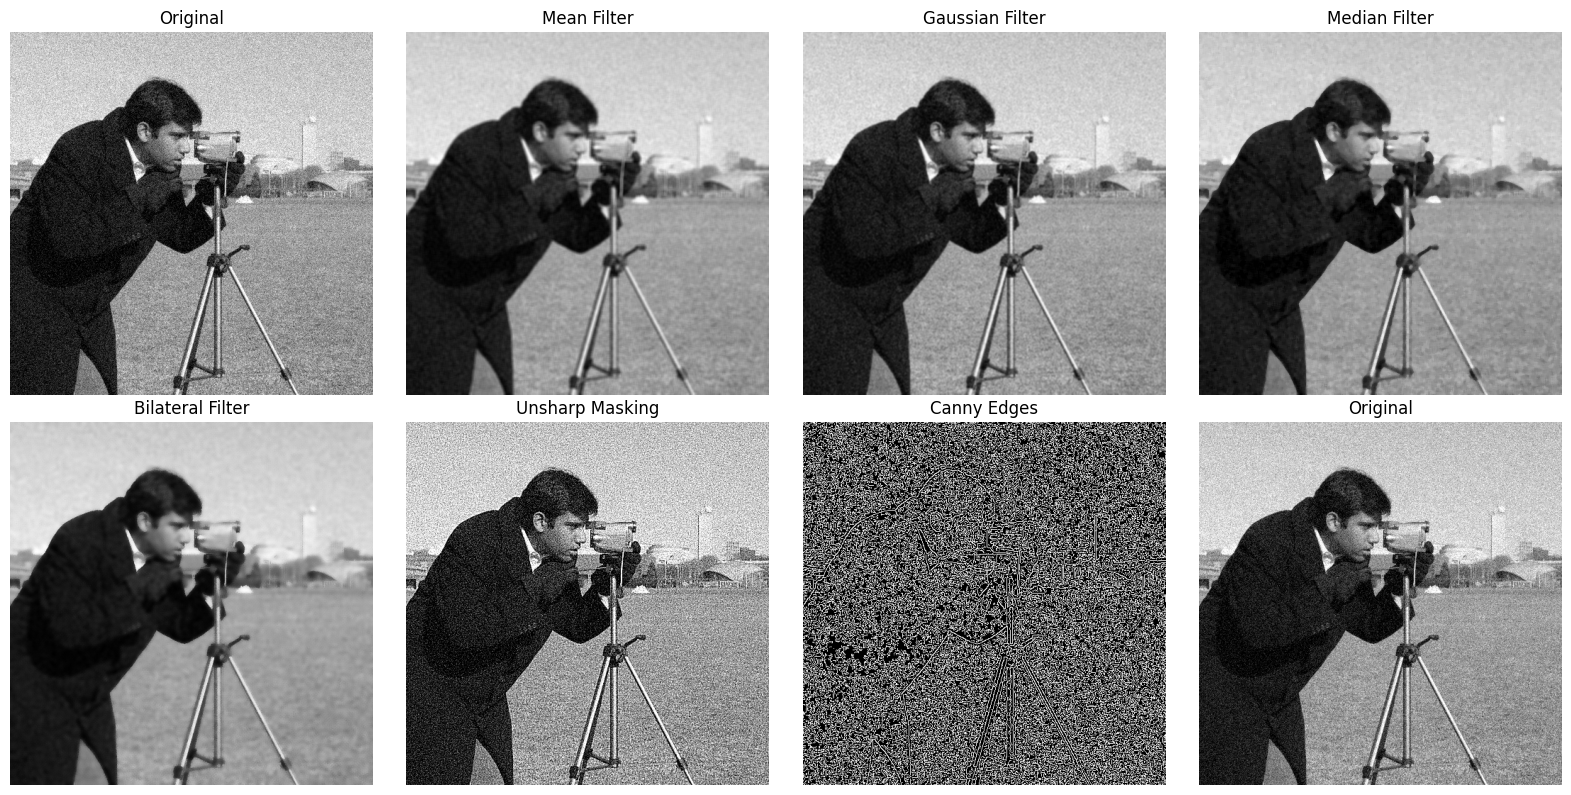

🔍 Spatial filtering uses neighborhood information:
  • Mean/Gaussian: smooth noise but blur edges
  • Median: excellent for salt & pepper noise
  • Bilateral: edge-preserving smoothing
  • Unsharp masking: enhances edges and details


In [6]:
def demonstrate_spatial_filtering(image):
    """Demonstrate spatial filtering for noise reduction and sharpening."""
    
    # Apply different filters
    mean_filtered = cv2.blur(image, (5, 5))
    gaussian_filtered = cv2.GaussianBlur(image, (5, 5), 1.0)
    median_filtered = cv2.medianBlur(image, 5)
    bilateral_filtered = cv2.bilateralFilter(image, 9, 75, 75)
    
    # Sharpening using unsharp masking
    blurred = cv2.GaussianBlur(image, (5, 5), 2.0)
    mask = image.astype(float) - blurred.astype(float)
    sharpened = image.astype(float) + 1.0 * mask
    sharpened = np.clip(sharpened, 0, 255).astype(np.uint8)
    
    # Edge detection
    edges = cv2.Canny(image, 50, 150)
    
    # Visualize results
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    
    filters_results = [
        (image, "Original"),
        (mean_filtered, "Mean Filter"),
        (gaussian_filtered, "Gaussian Filter"),
        (median_filtered, "Median Filter"),
        (bilateral_filtered, "Bilateral Filter"),
        (sharpened, "Unsharp Masking"),
        (edges, "Canny Edges"),
        (image, "Original")
    ]
    
    for i, (result, title) in enumerate(filters_results):
        row = i // 4
        col = i % 4
        if title == "Canny Edges":
            axes[row, col].imshow(result, cmap='gray')
        else:
            axes[row, col].imshow(result, cmap='gray')
        axes[row, col].set_title(title)
        axes[row, col].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return bilateral_filtered, sharpened

# Demonstrate spatial filtering
filtered_result, sharpened_result = demonstrate_spatial_filtering(camera_problems['noisy'])

print("🔍 Spatial filtering uses neighborhood information:")
print("  • Mean/Gaussian: smooth noise but blur edges")
print("  • Median: excellent for salt & pepper noise")
print("  • Bilateral: edge-preserving smoothing")
print("  • Unsharp masking: enhances edges and details")

## 4. Part 3: Advanced Techniques
Let's explore more sophisticated enhancement methods.

🔧 Building comprehensive enhancement pipeline...
  ✓ Step 1: Noise reduction with bilateral filter
  ✓ Step 2: Contrast enhancement with CLAHE
  ✓ Step 3: Brightness adjustment with gamma correction
  ✓ Step 4: Detail enhancement with unsharp masking


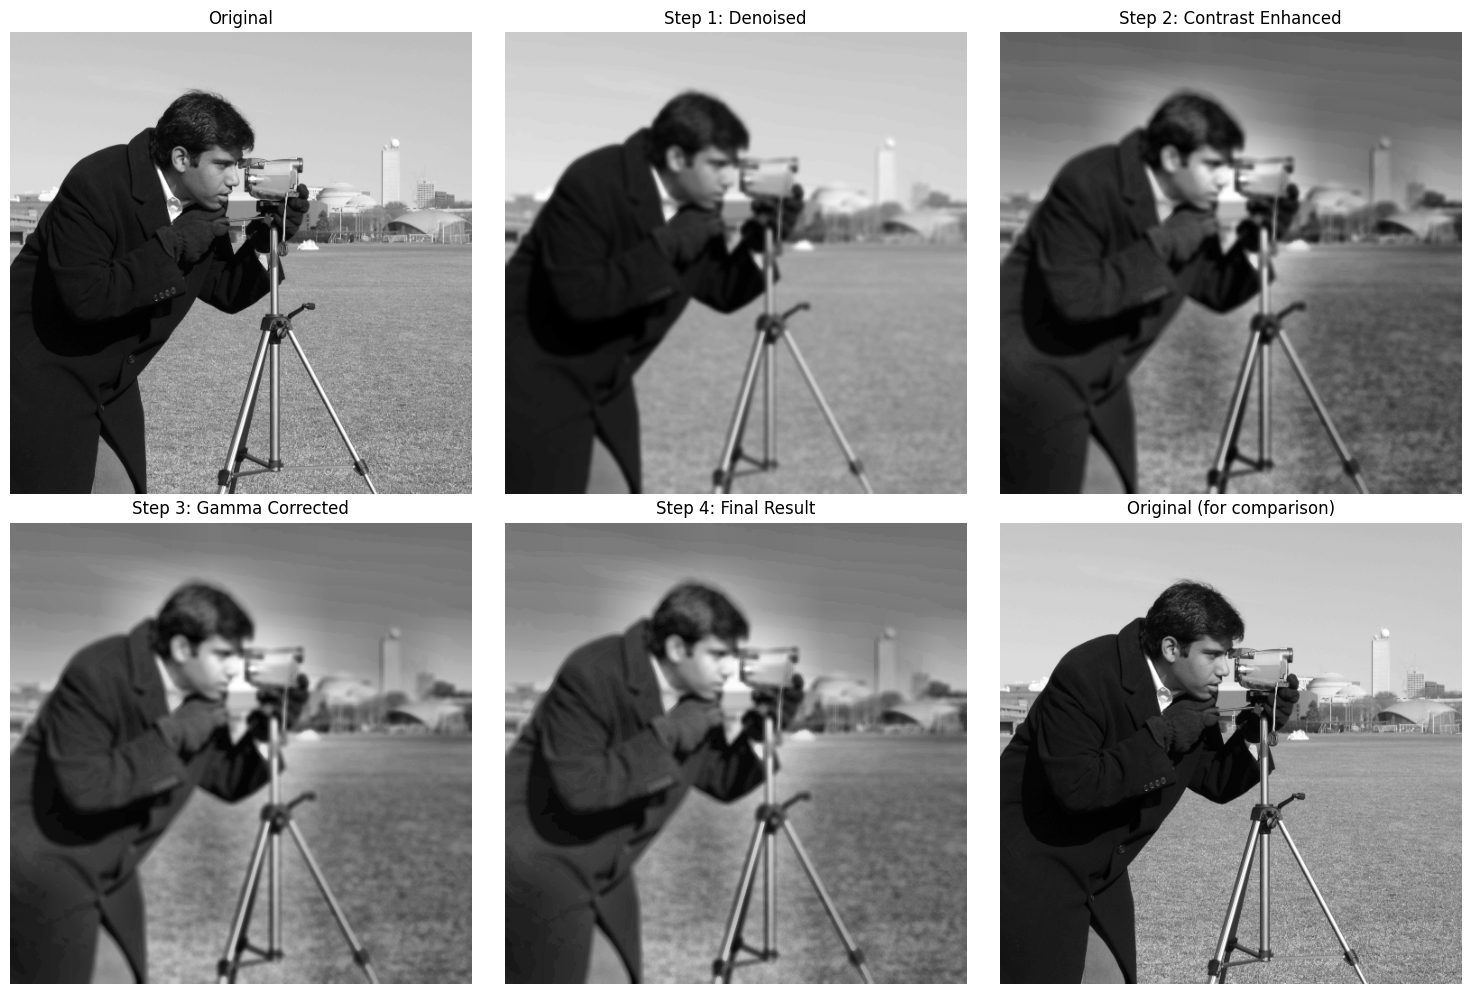

In [7]:
def advanced_enhancement_pipeline(image):
    """Demonstrate a complete enhancement pipeline."""
    
    print("🔧 Building comprehensive enhancement pipeline...")
    
    # Step 1: Noise reduction
    denoised = cv2.bilateralFilter(image, 9, 75, 75)
    print("  ✓ Step 1: Noise reduction with bilateral filter")
    
    # Step 2: Contrast enhancement
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    contrast_enhanced = clahe.apply(denoised)
    print("  ✓ Step 2: Contrast enhancement with CLAHE")
    
    # Step 3: Gamma correction for brightness
    gamma_corrected = gamma_correction(contrast_enhanced, 0.8)
    print("  ✓ Step 3: Brightness adjustment with gamma correction")
    
    # Step 4: Sharpening
    blurred = cv2.GaussianBlur(gamma_corrected, (3, 3), 1.0)
    mask = gamma_corrected.astype(float) - blurred.astype(float)
    final_result = gamma_corrected.astype(float) + 0.5 * mask
    final_result = np.clip(final_result, 0, 255).astype(np.uint8)
    print("  ✓ Step 4: Detail enhancement with unsharp masking")
    
    # Visualize pipeline steps
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    pipeline_steps = [
        (image, "Original"),
        (denoised, "Step 1: Denoised"),
        (contrast_enhanced, "Step 2: Contrast Enhanced"),
        (gamma_corrected, "Step 3: Gamma Corrected"),
        (final_result, "Step 4: Final Result"),
        (image, "Original (for comparison)")
    ]
    
    for i, (img, title) in enumerate(pipeline_steps):
        row = i // 3
        col = i % 3
        axes[row, col].imshow(img, cmap='gray')
        axes[row, col].set_title(title)
        axes[row, col].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return final_result

# Apply advanced enhancement pipeline
enhanced_result = advanced_enhancement_pipeline(camera_problems['dark'])

## 5. Part 4: Diagnostic Tools
Learn how to evaluate enhancement results quantitatively.

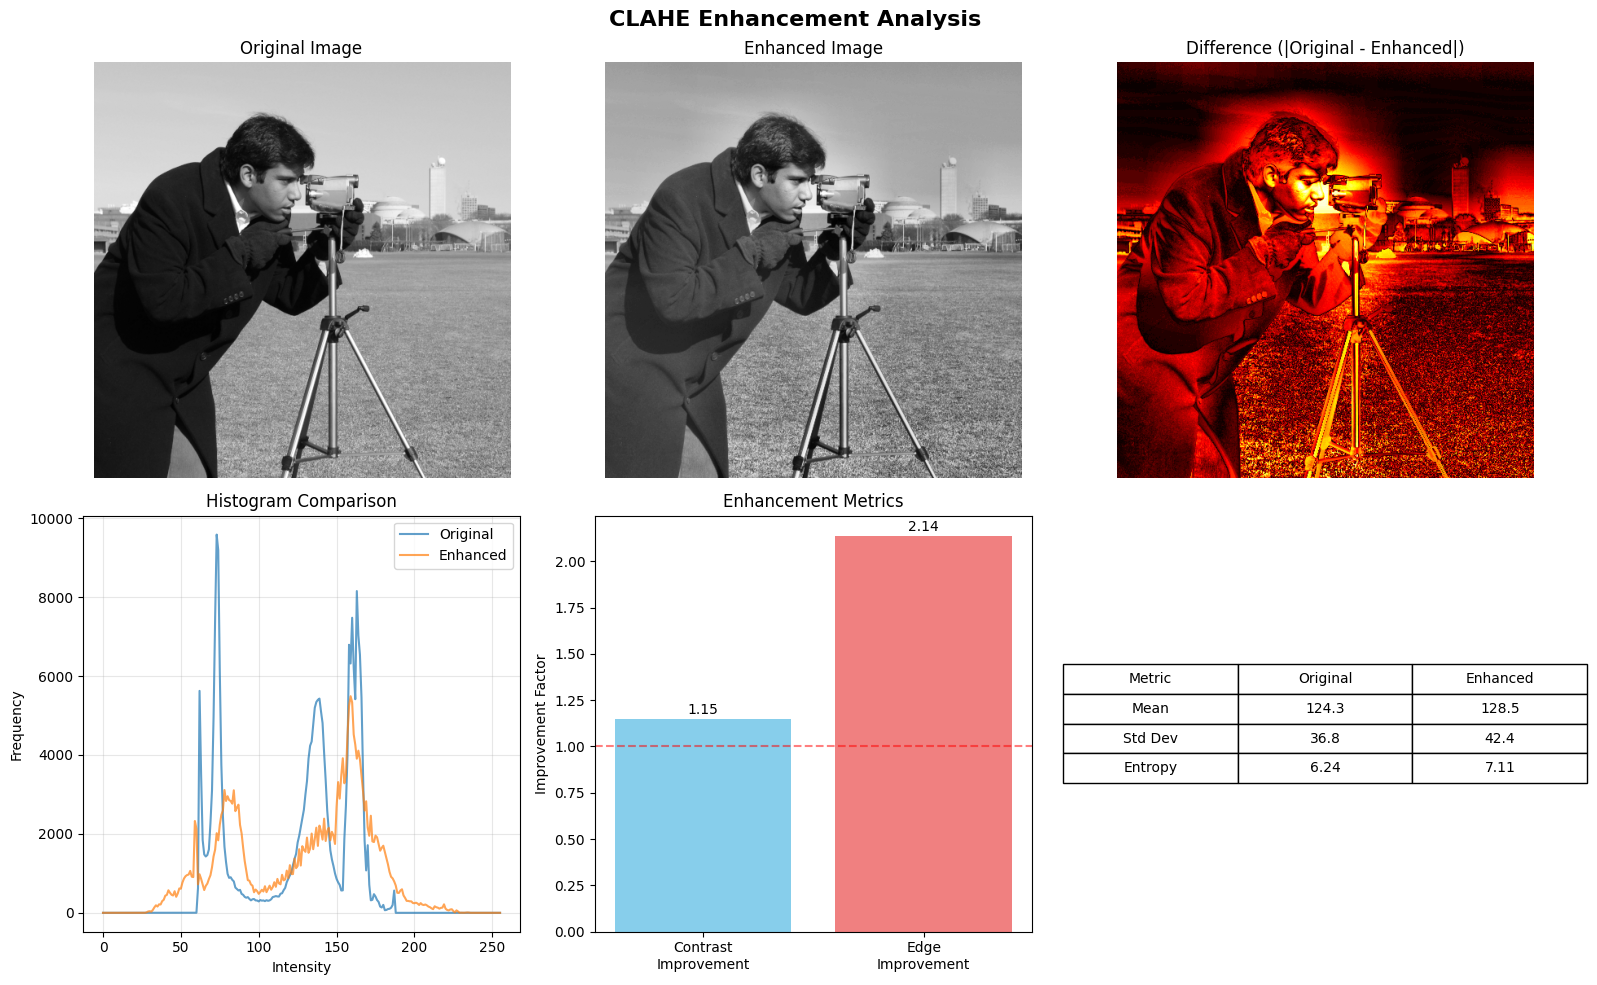

📊 CLAHE Enhancement Analysis - Detailed Analysis:
  📈 Contrast improvement: 1.15x
  🔍 Edge enhancement: 2.14x
  📊 Information content: 7.11 bits
  ✨ Overall assessment: Successful enhancement



In [8]:
def calculate_quality_metrics(original, enhanced):
    """Calculate various quality metrics for enhancement evaluation."""
    
    # Basic statistics
    orig_mean = np.mean(original)
    enh_mean = np.mean(enhanced)
    orig_std = np.std(original)
    enh_std = np.std(enhanced)
    
    # Contrast improvement
    contrast_improvement = enh_std / orig_std if orig_std > 0 else 1
    
    # Edge strength (using Sobel operator)
    def edge_strength(img):
        sobel_x = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
        sobel_y = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
        return np.mean(np.sqrt(sobel_x**2 + sobel_y**2))
    
    orig_edge = edge_strength(original)
    enh_edge = edge_strength(enhanced)
    edge_improvement = enh_edge / orig_edge if orig_edge > 0 else 1
    
    # Entropy (information content)
    def calculate_entropy(img):
        hist = cv2.calcHist([img], [0], None, [256], [0, 256])
        hist = hist / hist.sum()
        entropy = -np.sum(hist * np.log2(hist + 1e-10))
        return entropy
    
    orig_entropy = calculate_entropy(original)
    enh_entropy = calculate_entropy(enhanced)
    
    return {
        'original_mean': orig_mean,
        'enhanced_mean': enh_mean,
        'original_std': orig_std,
        'enhanced_std': enh_std,
        'contrast_improvement': contrast_improvement,
        'edge_improvement': edge_improvement,
        'original_entropy': orig_entropy,
        'enhanced_entropy': enh_entropy
    }

def visualize_enhancement_analysis(original, enhanced, title="Enhancement Analysis"):
    """Comprehensive visualization of enhancement results."""
    
    # Calculate metrics
    metrics = calculate_quality_metrics(original, enhanced)
    
    # Create visualization
    fig = plt.figure(figsize=(16, 10))
    
    # Images comparison
    ax1 = plt.subplot(2, 3, 1)
    plt.imshow(original, cmap='gray')
    plt.title('Original Image')
    plt.axis('off')
    
    ax2 = plt.subplot(2, 3, 2)
    plt.imshow(enhanced, cmap='gray')
    plt.title('Enhanced Image')
    plt.axis('off')
    
    # Difference image
    ax3 = plt.subplot(2, 3, 3)
    diff = cv2.absdiff(original, enhanced)
    plt.imshow(diff, cmap='hot')
    plt.title('Difference (|Original - Enhanced|)')
    plt.axis('off')
    
    # Histograms comparison
    ax4 = plt.subplot(2, 3, 4)
    hist_orig = cv2.calcHist([original], [0], None, [256], [0, 256])
    hist_enh = cv2.calcHist([enhanced], [0], None, [256], [0, 256])
    plt.plot(hist_orig, label='Original', alpha=0.7)
    plt.plot(hist_enh, label='Enhanced', alpha=0.7)
    plt.title('Histogram Comparison')
    plt.xlabel('Intensity')
    plt.ylabel('Frequency')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Metrics visualization
    ax5 = plt.subplot(2, 3, 5)
    metric_names = ['Contrast\nImprovement', 'Edge\nImprovement']
    metric_values = [metrics['contrast_improvement'], metrics['edge_improvement']]
    bars = plt.bar(metric_names, metric_values, color=['skyblue', 'lightcoral'])
    plt.title('Enhancement Metrics')
    plt.ylabel('Improvement Factor')
    plt.axhline(y=1, color='red', linestyle='--', alpha=0.5, label='No improvement')
    
    # Add value labels on bars
    for bar, value in zip(bars, metric_values):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{value:.2f}', ha='center', va='bottom')
    
    # Statistics table
    ax6 = plt.subplot(2, 3, 6)
    ax6.axis('tight')
    ax6.axis('off')
    
    table_data = [
        ['Metric', 'Original', 'Enhanced'],
        ['Mean', f"{metrics['original_mean']:.1f}", f"{metrics['enhanced_mean']:.1f}"],
        ['Std Dev', f"{metrics['original_std']:.1f}", f"{metrics['enhanced_std']:.1f}"],
        ['Entropy', f"{metrics['original_entropy']:.2f}", f"{metrics['enhanced_entropy']:.2f}"]
    ]
    
    table = ax6.table(cellText=table_data, cellLoc='center', loc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 1.5)
    
    plt.suptitle(title, fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Print detailed analysis
    print(f"📊 {title} - Detailed Analysis:")
    print(f"  📈 Contrast improvement: {metrics['contrast_improvement']:.2f}x")
    print(f"  🔍 Edge enhancement: {metrics['edge_improvement']:.2f}x")
    print(f"  📊 Information content: {metrics['enhanced_entropy']:.2f} bits")
    print(f"  ✨ Overall assessment: {'Successful' if metrics['contrast_improvement'] > 1.1 else 'Moderate'} enhancement")
    print()

# Analyze enhancement results
visualize_enhancement_analysis(
    camera_problems['low_contrast'], 
    clahe_result, 
    "CLAHE Enhancement Analysis"
)

## 6. Part 5: Best Practices
Learn common pitfalls and how to avoid them.

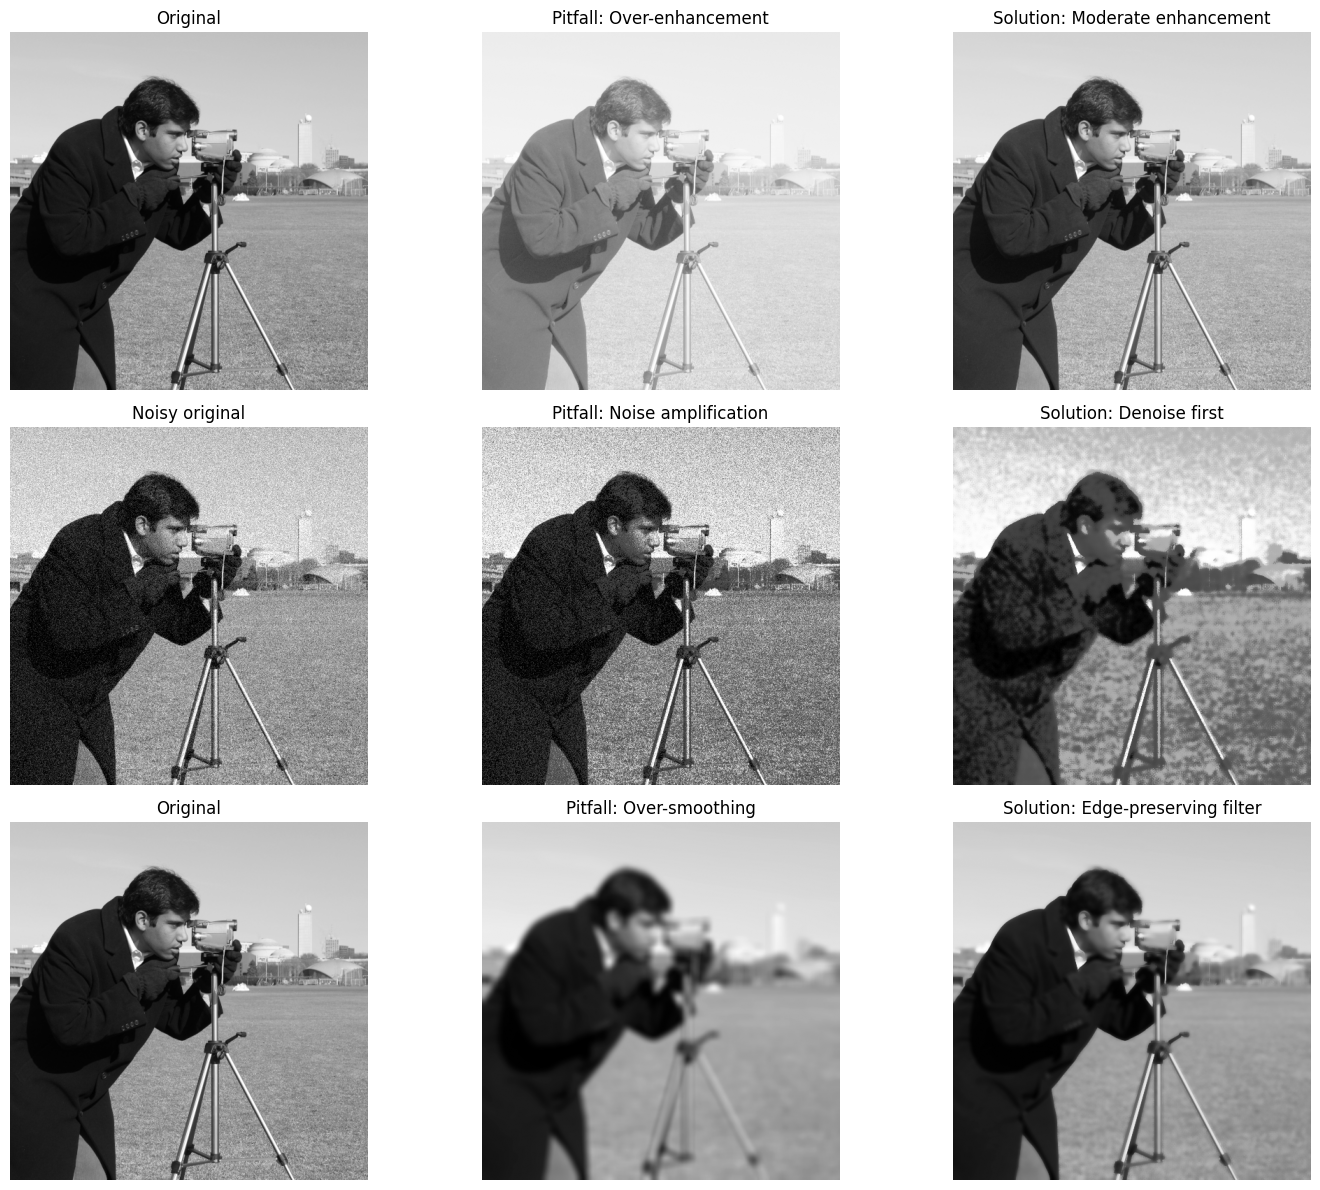

⚠️  Common Enhancement Pitfalls:
  🚫 Over-enhancement: Creates unnatural-looking images
  🔊 Noise amplification: Enhancement makes noise worse
  🌫️  Loss of detail: Excessive smoothing removes important features

✅ Best Practices:
  ✓ Use moderate enhancement parameters
  ✓ Apply noise reduction before enhancement
  ✓ Use edge-preserving filters when possible
  ✓ Always validate results visually and quantitatively


In [9]:
def demonstrate_common_pitfalls():
    """Show common enhancement pitfalls and solutions."""
    
    original = samples['camera']
    
    # Pitfall 1: Over-enhancement
    over_enhanced = gamma_correction(original, 0.3)  # Extreme gamma
    
    # Pitfall 2: Noise amplification
    noisy = camera_problems['noisy']
    amplified_noise = cv2.equalizeHist(noisy)  # Hist eq on noisy image
    
    # Pitfall 3: Loss of detail
    over_smoothed = cv2.GaussianBlur(original, (15, 15), 5.0)  # Excessive smoothing
    
    # Solutions
    moderate_enhancement = gamma_correction(original, 0.7)  # Moderate gamma
    proper_denoising = cv2.bilateralFilter(noisy, 9, 75, 75)
    proper_denoising = cv2.equalizeHist(proper_denoising)  # Denoise first
    edge_preserving = cv2.bilateralFilter(original, 9, 75, 75)  # Edge-preserving
    
    # Visualize pitfalls and solutions
    fig, axes = plt.subplots(3, 3, figsize=(15, 12))
    
    examples = [
        # Row 1: Over-enhancement
        (original, "Original"),
        (over_enhanced, "Pitfall: Over-enhancement"),
        (moderate_enhancement, "Solution: Moderate enhancement"),
        
        # Row 2: Noise amplification
        (noisy, "Noisy original"),
        (amplified_noise, "Pitfall: Noise amplification"),
        (proper_denoising, "Solution: Denoise first"),
        
        # Row 3: Loss of detail
        (original, "Original"),
        (over_smoothed, "Pitfall: Over-smoothing"),
        (edge_preserving, "Solution: Edge-preserving filter")
    ]
    
    for i, (img, title) in enumerate(examples):
        row = i // 3
        col = i % 3
        axes[row, col].imshow(img, cmap='gray')
        axes[row, col].set_title(title)
        axes[row, col].axis('off')
        
        # Add colored borders for pitfalls and solutions
        if "Pitfall" in title:
            for spine in axes[row, col].spines.values():
                spine.set_edgecolor('red')
                spine.set_linewidth(3)
        elif "Solution" in title:
            for spine in axes[row, col].spines.values():
                spine.set_edgecolor('green')
                spine.set_linewidth(3)
    
    plt.tight_layout()
    plt.show()

demonstrate_common_pitfalls()

print("⚠️  Common Enhancement Pitfalls:")
print("  🚫 Over-enhancement: Creates unnatural-looking images")
print("  🔊 Noise amplification: Enhancement makes noise worse")
print("  🌫️  Loss of detail: Excessive smoothing removes important features")
print()
print("✅ Best Practices:")
print("  ✓ Use moderate enhancement parameters")
print("  ✓ Apply noise reduction before enhancement")
print("  ✓ Use edge-preserving filters when possible")
print("  ✓ Always validate results visually and quantitatively")

## 7. Student Activity (15 minutes)
**Challenge:** Apply appropriate enhancement techniques to improve the given problematic images.

**Instructions:**
1. Analyze each problematic image
2. Choose and apply appropriate enhancement technique(s)
3. Evaluate your results using the quality metrics
4. Explain your choice of techniques

🎯 STUDENT ACTIVITY: Enhancement Challenge


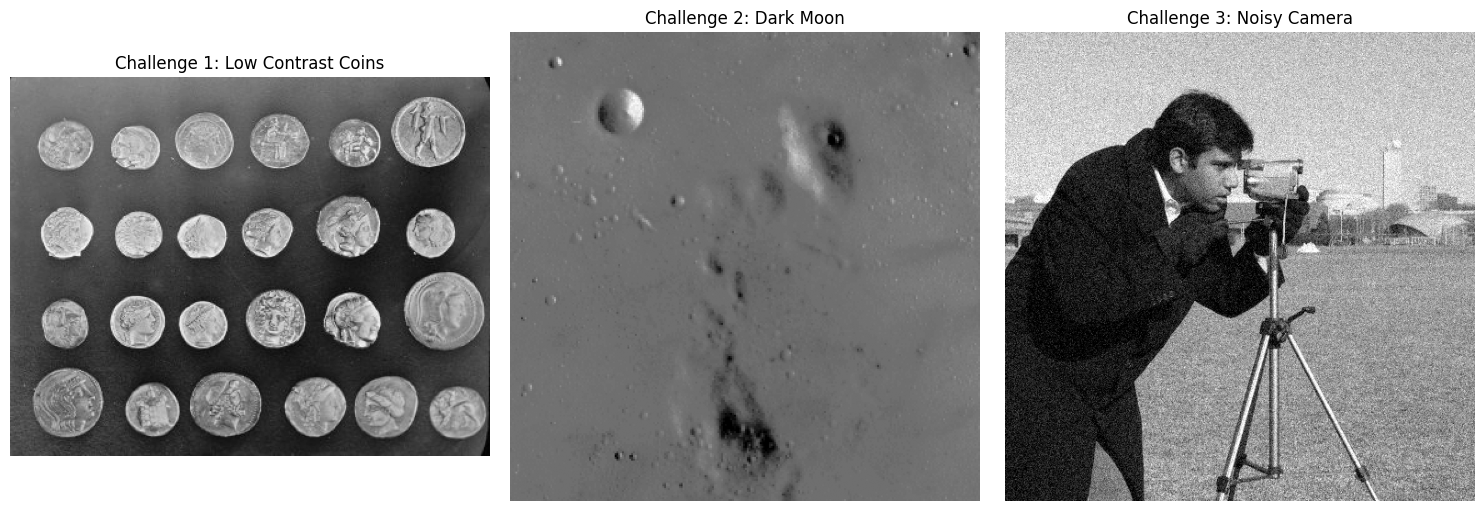


📝 Your Tasks:
1. Analyze each image and identify the main problems
2. Apply appropriate enhancement techniques
3. Use the quality metrics to evaluate your results
4. Explain why you chose each technique

💻 Use the cells below for your solutions:


In [10]:
# Student Activity: Enhancement Challenge
print("🎯 STUDENT ACTIVITY: Enhancement Challenge")
print("=" * 50)

# Load challenge images
challenge_images = {
    'low_contrast_coins': (data.coins() * 0.4 + 80).astype(np.uint8),
    'dark_moon': (data.moon() * 0.3).astype(np.uint8),
    'noisy_camera': camera_problems['noisy']
}

# Display challenge images
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, (name, img) in enumerate(challenge_images.items()):
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f'Challenge {i+1}: {name.replace("_", " ").title()}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

print("\n📝 Your Tasks:")
print("1. Analyze each image and identify the main problems")
print("2. Apply appropriate enhancement techniques")
print("3. Use the quality metrics to evaluate your results")
print("4. Explain why you chose each technique")

# Workspace for student solutions
print("\n💻 Use the cells below for your solutions:")

# Store challenge images for student use
challenge_1 = challenge_images['low_contrast_coins']
challenge_2 = challenge_images['dark_moon']
challenge_3 = challenge_images['noisy_camera']

In [11]:
# Student Solution Space - Challenge 1: Low Contrast Coins
# TODO: Analyze and enhance the low contrast coins image

# Your code here:
# solution_1 = ...

# Uncomment to test your solution:
# visualize_enhancement_analysis(challenge_1, solution_1, "Challenge 1 Solution")

In [12]:
# Student Solution Space - Challenge 2: Dark Moon
# TODO: Analyze and enhance the dark moon image

# Your code here:
# solution_2 = ...

# Uncomment to test your solution:
# visualize_enhancement_analysis(challenge_2, solution_2, "Challenge 2 Solution")

In [13]:
# Student Solution Space - Challenge 3: Noisy Camera
# TODO: Analyze and enhance the noisy camera image

# Your code here:
# solution_3 = ...

# Uncomment to test your solution:
# visualize_enhancement_analysis(challenge_3, solution_3, "Challenge 3 Solution")

## 8. Solutions
<details>
<summary><b>🔍 Click to reveal solutions (try the activity first!)</b></summary>

### Challenge 1: Low Contrast Coins
**Problem:** Poor contrast makes coin details hard to see  
**Solution:** CLAHE for adaptive contrast enhancement

### Challenge 2: Dark Moon
**Problem:** Underexposed image, details lost in shadows  
**Solution:** Gamma correction (γ < 1) to brighten + contrast stretching

### Challenge 3: Noisy Camera
**Problem:** High noise level obscures image details  
**Solution:** Bilateral filtering for edge-preserving denoising + mild contrast enhancement
</details>

In [14]:
# Hidden Solutions (run this cell to see example solutions)
def show_solutions():
    """Show example solutions for the challenges."""
    
    # Solution 1: Low contrast coins - use CLAHE
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    solution_1 = clahe.apply(challenge_1)
    
    # Solution 2: Dark moon - gamma correction + contrast stretching
    gamma_bright = gamma_correction(challenge_2, 0.6)
    solution_2 = exposure.rescale_intensity(gamma_bright)
    
    # Solution 3: Noisy camera - bilateral filter + mild enhancement
    denoised = cv2.bilateralFilter(challenge_3, 9, 75, 75)
    solution_3 = gamma_correction(denoised, 0.9)
    
    # Display solutions
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    challenges = [challenge_1, challenge_2, challenge_3]
    solutions = [solution_1, solution_2, solution_3]
    titles = ['Low Contrast Coins', 'Dark Moon', 'Noisy Camera']
    
    for i in range(3):
        # Original challenges
        axes[0, i].imshow(challenges[i], cmap='gray')
        axes[0, i].set_title(f'Challenge {i+1}: {titles[i]}')
        axes[0, i].axis('off')
        
        # Solutions
        axes[1, i].imshow(solutions[i], cmap='gray')
        axes[1, i].set_title(f'Solution {i+1}')
        axes[1, i].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print("💡 Solution Explanations:")
    print("  1️⃣ CLAHE: Adaptive contrast enhancement preserves local details")
    print("  2️⃣ Gamma + Stretching: Brightens shadows while maintaining highlights")
    print("  3️⃣ Bilateral + Gamma: Denoises while preserving edges, slight brightening")

# Uncomment to see solutions:
# show_solutions()

## 9. Summary
Congratulations! You've completed the Basic Enhancement workshop. Let's review what we've learned.

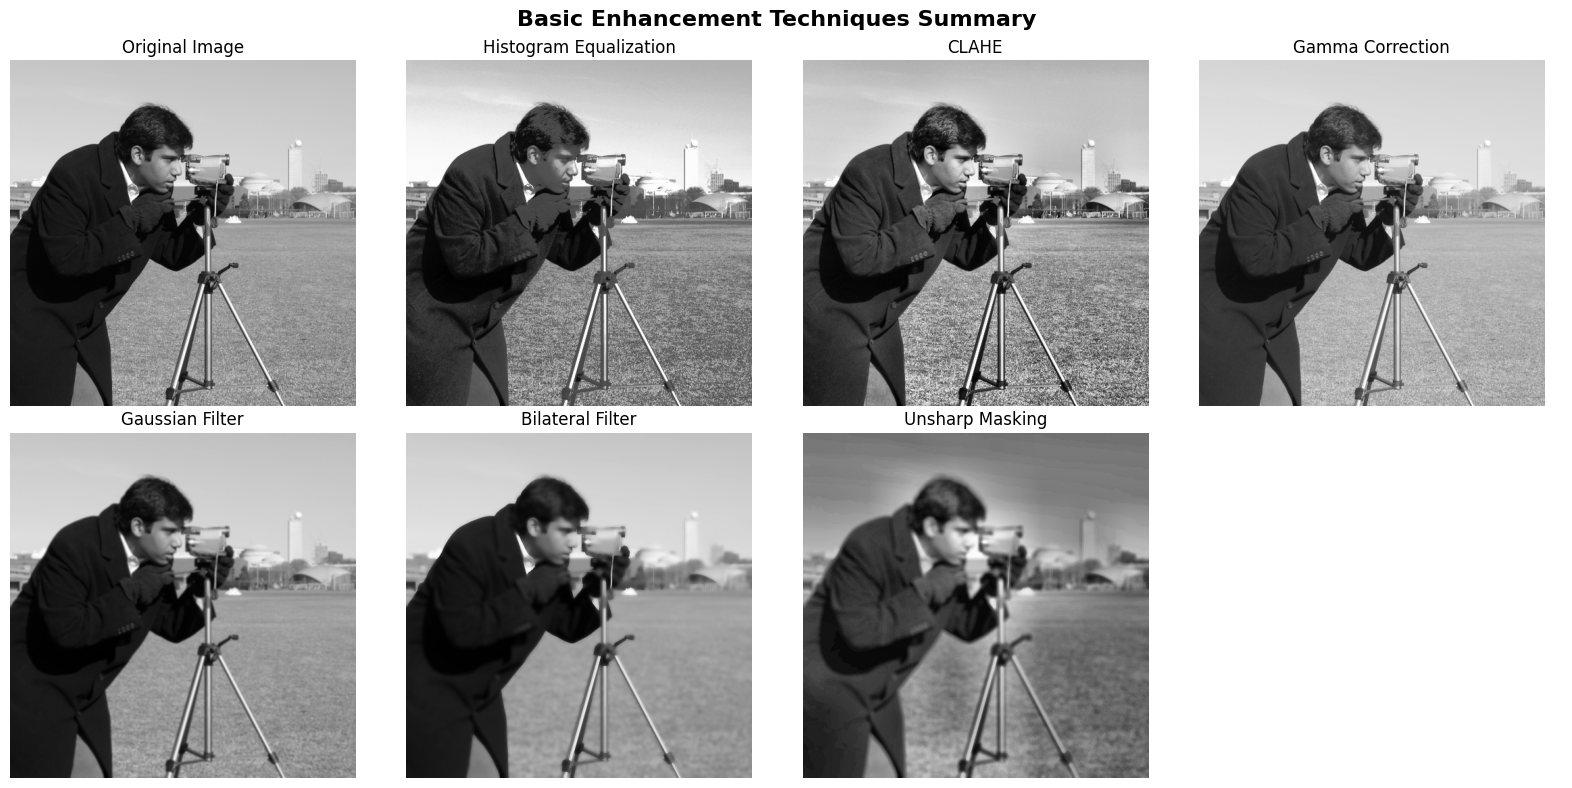

🎓 WORKSHOP SUMMARY

✅ What You've Learned:
  📊 Histogram analysis and equalization techniques
  ⚡ Point operations for brightness/contrast adjustment
  🔍 Spatial filtering for noise reduction and sharpening
  📈 Quality metrics for objective evaluation
  ⚠️  Common pitfalls and how to avoid them

🛠️ Key Techniques Mastered:
  • Histogram Equalization & CLAHE
  • Gamma Correction
  • Gaussian & Bilateral Filtering
  • Unsharp Masking
  • Edge Detection with Canny

🎯 Next Steps:
  • Practice with your own images
  • Explore frequency domain enhancement
  • Study advanced morphological operations
  • Learn about machine learning-based enhancement

🏆 Well done! You're now equipped with fundamental image enhancement skills!


In [15]:
# Create a comprehensive summary visualization
def create_summary_visualization():
    """Create a summary of all enhancement techniques."""
    
    original = samples['camera']
    
    # Apply different techniques for summary
    techniques = {
        'Histogram Equalization': cv2.equalizeHist(original),
        'CLAHE': cv2.createCLAHE(clipLimit=2.0).apply(original),
        'Gamma Correction': gamma_correction(original, 0.7),
        'Gaussian Filter': cv2.GaussianBlur(original, (5, 5), 1.0),
        'Bilateral Filter': cv2.bilateralFilter(original, 9, 75, 75),
        'Unsharp Masking': enhanced_result  # From earlier
    }
    
    # Create summary visualization
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.ravel()
    
    # Original image
    axes[0].imshow(original, cmap='gray')
    axes[0].set_title('Original Image')
    axes[0].axis('off')
    
    # Enhanced versions
    for i, (name, img) in enumerate(techniques.items(), 1):
        if i < 7:  # Only show first 6 techniques
            axes[i].imshow(img, cmap='gray')
            axes[i].set_title(name)
            axes[i].axis('off')
    
    # Hide unused subplot
    axes[7].axis('off')
    
    plt.suptitle('Basic Enhancement Techniques Summary', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

create_summary_visualization()

print("🎓 WORKSHOP SUMMARY")
print("=" * 50)
print("\n✅ What You've Learned:")
print("  📊 Histogram analysis and equalization techniques")
print("  ⚡ Point operations for brightness/contrast adjustment")
print("  🔍 Spatial filtering for noise reduction and sharpening")
print("  📈 Quality metrics for objective evaluation")
print("  ⚠️  Common pitfalls and how to avoid them")
print("\n🛠️ Key Techniques Mastered:")
print("  • Histogram Equalization & CLAHE")
print("  • Gamma Correction")
print("  • Gaussian & Bilateral Filtering")
print("  • Unsharp Masking")
print("  • Edge Detection with Canny")
print("\n🎯 Next Steps:")
print("  • Practice with your own images")
print("  • Explore frequency domain enhancement")
print("  • Study advanced morphological operations")
print("  • Learn about machine learning-based enhancement")
print("\n🏆 Well done! You're now equipped with fundamental image enhancement skills!")